# SHL Grammar Scoring Engine

Predict the grammar score (0 to 5) of a 45 to 60 second spoken English clip.

**Approach in one line:** transcribe each clip with Whisper, describe the transcript (and the audio) with a few explainable features plus pretrained embeddings, and fit a ridge regression. Cross-validation decides which feature groups are worth keeping.

**Where things run**
- `kaggle_transcribe.ipynb` runs once on a Kaggle GPU: Whisper transcripts, text and audio embeddings, sentence acceptability scores. Its outputs are saved in `outputs/`.
- This notebook runs on a laptop CPU in about a minute (plus a few minutes the first time, for LanguageTool). It builds the features, trains and evaluates the model, and writes `outputs/submission.csv`.

**Contents**
1. Approach and pipeline
2. Setup
3. Data and label distribution
4. Transcripts
5. Hand-crafted features
6. Embeddings
7. Choosing feature groups with cross-validation
8. Final model: CV metrics and training RMSE
9. What the model learned
10. Test predictions and submission
11. Report summary

## 1. Approach and pipeline

The score is about grammar, which is mostly visible in *what* is said, so the core of the pipeline works on transcripts. Audio features are added to cover what the transcript misses (hesitation, rhythm), and only kept if cross-validation shows they help.

```
                 Kaggle GPU (once)                              This notebook (CPU)
 .wav clip ─┬─► Whisper medium.en ─► transcript ─┬─► hand-crafted text features ─┐
            │                                    ├─► LanguageTool error rates ───┤
            │                                    ├─► CoLA acceptability ─────────┤
            │                                    └─► MPNet / DeBERTa embedding ──┼─► ridge regression ─► clip to 0..5
            ├─► timing stats (duration, pauses) ─────────────────────────────────┤
            └─► WavLM audio embedding ───────────────────────────────────────────┘
```

**Why each piece**
- **Whisper** is a strong, widely used speech recogniser. The English-only medium model is accurate on accented speech and fast enough on a free GPU.
- **Hand-crafted features** map directly to the rubric: sentence length and subordinate clauses (structure), grammar error rates from LanguageTool and a CoLA classifier (accuracy), speech rate, pauses, fillers and repetitions (fluency, which raters are influenced by).
- **Embeddings** from pretrained text encoders summarise the whole transcript in one vector, picking up vocabulary and phrasing patterns that simple counts miss.
- **Ridge regression** is a linear model with a penalty on large weights. With about 770 training clips and hundreds of embedding dimensions, that penalty is what keeps it from overfitting. It is fast, stable and easy to inspect.
- **5-fold cross-validation** gives an honest estimate of test performance and is the only thing used to make modelling choices.

## 2. Setup

In [1]:
import random
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))  # make the src/ package importable

from src.data import OUTPUT_DIR, load_dataset, load_embedding, load_row_features, write_submission
from src.features import build_handcrafted, languagetool_features, remove_asr_loops
from src.train import SEED, SCORE_RANGE, compare_feature_sets, cross_validate, make_model, pearson, predict_clipped, rmse

# Fixed seeds so every number in this notebook is reproducible.
random.seed(SEED)
np.random.seed(SEED)

# Plot style: one accent colour for the data, a second only where two series are compared,
# grey for reference lines, and a light grid that stays in the background.
BLUE, ORANGE, INK, MUTED, GRID, LIGHT_BLUE = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e", "#e6e5e0", "#cde2fb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 9.5, "legend.frameon": False,
})
pd.set_option("display.precision", 3)

## 3. Data and label distribution

`load_dataset` joins the transcripts from the Kaggle notebook with the labels in `data/train.csv`. Column names are detected from the files rather than assumed, and printed below.

In [2]:
clips, sub_columns = load_dataset()

# Whisper got stuck repeating a phrase on a few clips ("tap tap tap ..."). Collapse those runs first.
cleaned = clips["transcript"].map(remove_asr_loops)
print(f"Transcripts with a Whisper loop removed: {(cleaned != clips['transcript']).sum()}")
clips["transcript"] = cleaned

is_train = (clips["split"] == "train").to_numpy()
train = clips[is_train].reset_index(drop=True)
y = train["label"].to_numpy()

print(f"Training clips: {is_train.sum()}, test clips: {(~is_train).sum()}")
print(f"Score mean {y.mean():.3f}, std {y.std():.3f}, range {y.min()} to {y.max()}")
print(f"Baseline: predicting the mean for every clip gives RMSE = std = {rmse(y, np.full_like(y, y.mean())):.3f}")

file column 'filename', score column 'label'


Transcripts with a Whisper loop removed: 5
Training clips: 769, test clips: 216
Score mean 3.313, std 1.238, range 0.0 to 5.0
Baseline: predicting the mean for every clip gives RMSE = std = 1.238


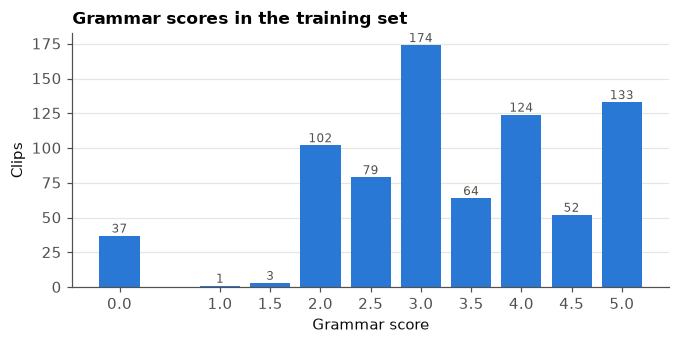

In [3]:
counts = train["label"].value_counts().sort_index()
step = np.diff(counts.index).min() if len(counts) > 1 else 1.0

fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(counts.index, counts.values, width=0.8 * step, color=BLUE)
for score, n in counts.items():
    ax.annotate(str(n), (score, n), xytext=(0, 2), textcoords="offset points", ha="center", color=MUTED, fontsize=8)
ax.set(title="Grammar scores in the training set", xlabel="Grammar score", ylabel="Clips", xticks=counts.index)
ax.grid(axis="x", visible=False)
plt.show()

The scores are not uniform: most clips sit in the middle of the scale and the extremes are rare. A model trained with squared error will therefore tend to pull extreme clips towards the middle, which shows up later in the residual plot. Because of this imbalance, the CV folds are stratified on the rounded score so every fold sees the full range.

## 4. Transcripts

A few transcripts from the low, middle and high end of the scale. Reading them is the quickest way to see what separates the levels: short, broken sentences and agreement errors at the bottom; longer, connected sentences with subordinate clauses at the top.

In [4]:
def show_examples(df, score, n=1, width=600):
    rows = df[df["label"] == score].head(n)
    for _, row in rows.iterrows():
        print(f"[score {row['label']}] {row['transcript'][:width]}{'...' if len(row['transcript']) > width else ''}\n")

for score in [counts.index.min(), counts.index[len(counts) // 2], counts.index.max()]:
    show_examples(train, score)

[score 0.0] Well, the wind dropped on my skin, I felt so free from the wind. Every time I would leave my home, I could make myself forget, at least, all that is ever to get into an accident, but just, blocking my heart, so I have two keys, and, let's go home.

[score 3.0] The playground is very, very beautiful and fun. There are playthings like the miracle round, the swing. The students usually enjoy the swing. It has to be like, it's more like a game of pay because one sits on it and the other will have to push and the male goes around and climbs on it. Most of them play football. Some parks parks, while others play swing. Some of the kids like to build sound classes and most times you hear the sound of screaming children laughing kids.

[score 5.0] The journey to fizzle land is an adventure in itself whether you arrive by plane, train or car. If you fly into Zurich or Geneva you will be greeted with a questioning view of the subsets as your plane descends towards the airport. From th

## 5. Hand-crafted features

Each feature is one number per clip that a rater could plausibly be reacting to:

| Feature | What it measures | Rubric link |
|---|---|---|
| `n_words`, `words_per_minute` | how much and how fast the speaker talks | fluency, ease with the language |
| `words_per_sentence` | average sentence length | sentence structure |
| `subordinator_rate` | words like *because, although, which* per 100 words | complex structures (levels 4 and 5) |
| `mean_word_length`, `lexical_diversity` | vocabulary range (Guiraud's index: unique words / sqrt(words)) | general proficiency |
| `filler_rate`, `repetition_rate` | *um, uh* and immediate repeats per 100 words | hesitation, self-correction |
| `voiced_ratio`, `long_pauses_per_minute` | share of the clip with speech, pauses of 0.5 s or more | fluency |
| `cola_mean`, `cola_min`, `cola_frac_bad` | sentence acceptability from a RoBERTa model trained on CoLA | grammatical accuracy |
| `lt_grammar_rate`, `lt_other_rate` | LanguageTool grammar and other errors per 100 words | grammatical accuracy |

LanguageTool is a rule-based grammar checker. Spelling, casing, punctuation and typography matches are ignored because they come from the transcription, not the speaker. Its results are cached in `outputs/languagetool_features.csv`, so later runs do not need Java.

In [5]:
lt = languagetool_features(clips, OUTPUT_DIR / "languagetool_features.csv")
cola = load_row_features("cola_features.csv", clips)
handcrafted = build_handcrafted(clips, cola, lt)

hc_train = handcrafted[is_train].reset_index(drop=True)
hc_train.describe().T[["mean", "std", "min", "max"]]

LanguageTool: 200/985


LanguageTool: 400/985


LanguageTool: 600/985


LanguageTool: 800/985


,mean,std,min,max
n_words,95.488,31.339,15.000,473.000
words_per_sentence,23.693,19.033,5.667,141.000
mean_word_length,4.235,0.412,3.343,5.873
lexical_diversity,5.871,0.910,3.491,8.573
filler_rate,0.027,0.346,0.000,8.421
repetition_rate,0.283,0.705,0.000,5.634
subordinator_rate,1.543,1.493,0.000,8.696
words_per_minute,103.639,32.064,14.981,472.412
voiced_ratio,0.718,0.153,0.038,1.000
long_pauses_per_minute,8.899,5.544,0.000,25.968


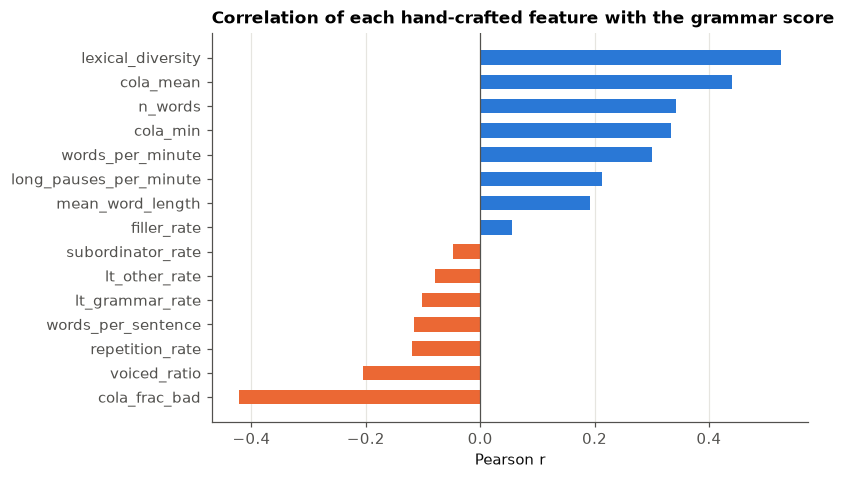

In [6]:
# How strongly does each feature move with the score on its own? (Pearson r on the training set)
corr = hc_train.apply(lambda col: pearson(y, col.fillna(col.median()))).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.barh(corr.index, corr.values, color=[ORANGE if v < 0 else BLUE for v in corr.values], height=0.6)
ax.axvline(0, color=MUTED, linewidth=0.8)
ax.set(title="Correlation of each hand-crafted feature with the grammar score", xlabel="Pearson r")
ax.grid(axis="y", visible=False)
plt.show()

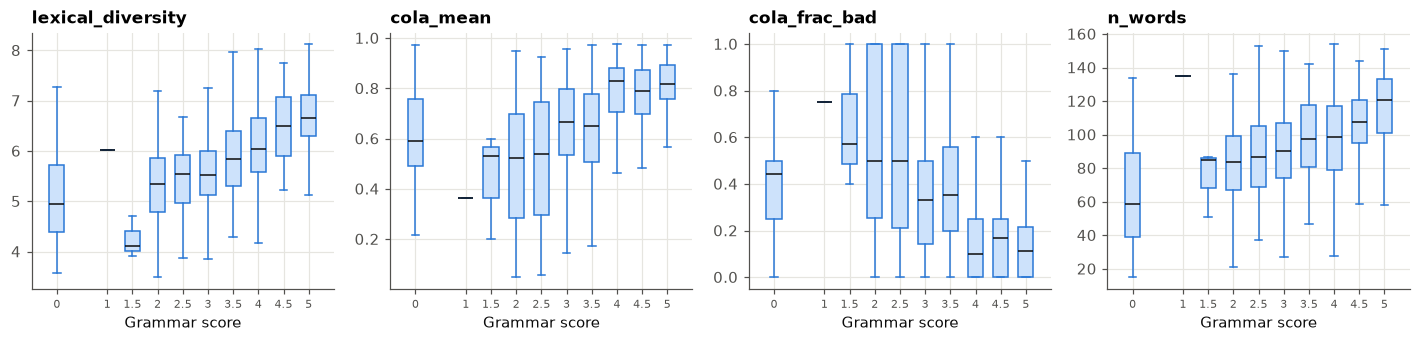

In [7]:
# The four most informative features, shown against the score.
top4 = corr.abs().sort_values(ascending=False).index[:4]
scores = counts.index.to_numpy()

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
for ax, feat in zip(axes, top4):
    groups = [hc_train.loc[y == s, feat].dropna() for s in scores]
    ax.boxplot(groups, positions=scores, widths=0.6 * step, patch_artist=True, showfliers=False,
               boxprops=dict(facecolor=LIGHT_BLUE, edgecolor=BLUE), medianprops=dict(color=INK),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE))
    ax.set(title=feat, xlabel="Grammar score")
    ax.set_xticks(scores, [f"{s:g}" for s in scores], fontsize=7)
fig.tight_layout()
plt.show()

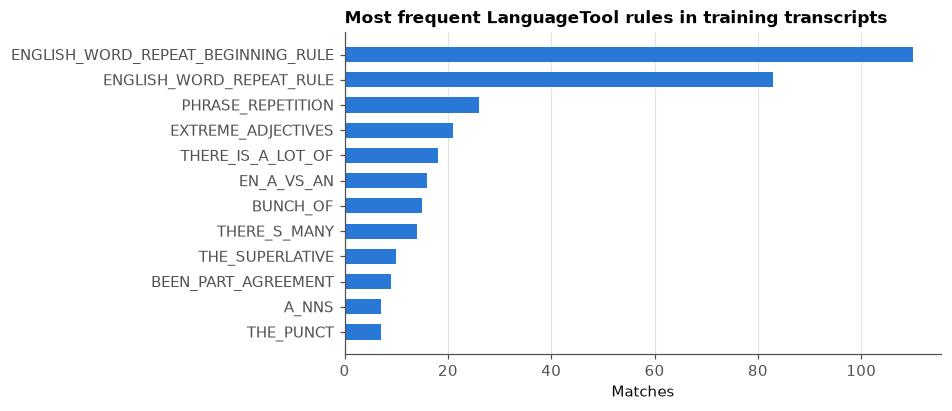

In [8]:
# Which LanguageTool rules fire most often? This shows what kinds of errors the checker actually sees.
rule_counts = Counter(r for rules in lt.loc[is_train, "lt_rules"] for r in str(rules).split(";") if r)
top_rules = pd.Series(dict(rule_counts.most_common(12))).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.barh(top_rules.index, top_rules.values, color=BLUE, height=0.6)
ax.set(title="Most frequent LanguageTool rules in training transcripts", xlabel="Matches")
ax.grid(axis="y", visible=False)
plt.show()

## 6. Embeddings

The Kaggle notebook saved one vector per clip from each pretrained model:

- **MPNet text** (768 numbers): `all-mpnet-base-v2`, a model trained to produce sentence embeddings.
- **DeBERTa text** (1024 numbers): `deberta-v3-large`, a general text encoder; token vectors are averaged.
- **WavLM audio** (768 numbers): `wavlm-base-plus`, a speech model run on the raw audio. Its frame vectors are averaged over time at every layer, and here we also average the 12 transformer layers, a common simple default that avoids tuning a layer choice.

Any group whose file is missing (for example if that Kaggle stage failed) is simply skipped below.

In [9]:
feature_groups = {"Hand-crafted": handcrafted.to_numpy(dtype=float)}
for file_key, name in [("text_mpnet", "MPNet text"), ("text_deberta", "DeBERTa text"), ("audio_wavlm", "WavLM audio")]:
    if not (OUTPUT_DIR / f"emb_{file_key}.npz").exists():
        print(f"{name}: not found, skipped")
        continue
    emb = load_embedding(file_key, clips)
    if emb.ndim == 3:  # WavLM: (clips, layers, dims) -> average the transformer layers 1..12
        emb = emb[:, 1:, :].mean(axis=1)
    feature_groups[name] = emb

for name, X in feature_groups.items():
    print(f"{name:14s} {X.shape[1]:5d} features")

Hand-crafted      15 features
MPNet text       768 features
DeBERTa text    1024 features
WavLM audio      768 features


## 7. Choosing feature groups with cross-validation

Every combination below is evaluated with the **same model** (ridge with its penalty picked by leave-one-out inside each training fold) and the **same 5 stratified folds**, so differences come from the features alone. Each clip gets an out-of-fold prediction from a model that never saw it, and the RMSE and Pearson correlation are computed on those predictions.

**Selection rule:** take the lowest CV RMSE, but prefer fewer feature groups unless the bigger set wins by more than 0.005 RMSE. This keeps the model as simple as the data allows.

In [10]:
candidates = [
    ["Hand-crafted"],
    ["MPNet text"],
    ["DeBERTa text"],
    ["WavLM audio"],
    ["Hand-crafted", "MPNet text"],
    ["Hand-crafted", "DeBERTa text"],
    ["Hand-crafted", "MPNet text", "WavLM audio"],
    ["Hand-crafted", "DeBERTa text", "WavLM audio"],
    ["Hand-crafted", "MPNet text", "DeBERTa text", "WavLM audio"],
]
candidates = [c for c in candidates if all(g in feature_groups for g in c)]
feature_sets = {" + ".join(c): np.hstack([feature_groups[g][is_train] for g in c]) for c in candidates}

ablation, oof_by_set = compare_feature_sets(feature_sets, y)
ablation["n_groups"] = [len(c) for c in candidates]

TOLERANCE = 0.005
best_rmse = ablation["cv_rmse"].min()
final_name = ablation[ablation["cv_rmse"] <= best_rmse + TOLERANCE].sort_values(["n_groups", "cv_rmse"]).index[0]
print("Chosen feature set:", final_name)
ablation.sort_values("cv_rmse")

Chosen feature set: Hand-crafted + DeBERTa text + WavLM audio


,n_features,cv_rmse,cv_rmse_fold_std,cv_pearson,n_groups
features,,,,,
Hand-crafted + DeBERTa text + WavLM audio,1807,0.529,0.050,0.905,3
Hand-crafted + MPNet text + DeBERTa text + WavLM audio,2575,0.546,0.057,0.898,4
Hand-crafted + MPNet text + WavLM audio,1551,0.566,0.045,0.890,3
WavLM audio,768,0.571,0.045,0.887,1
Hand-crafted + DeBERTa text,1039,0.738,0.068,0.803,2
DeBERTa text,1024,0.759,0.069,0.791,1
Hand-crafted,15,0.891,0.051,0.698,1
Hand-crafted + MPNet text,783,0.918,0.061,0.671,2
MPNet text,768,1.017,0.062,0.571,1


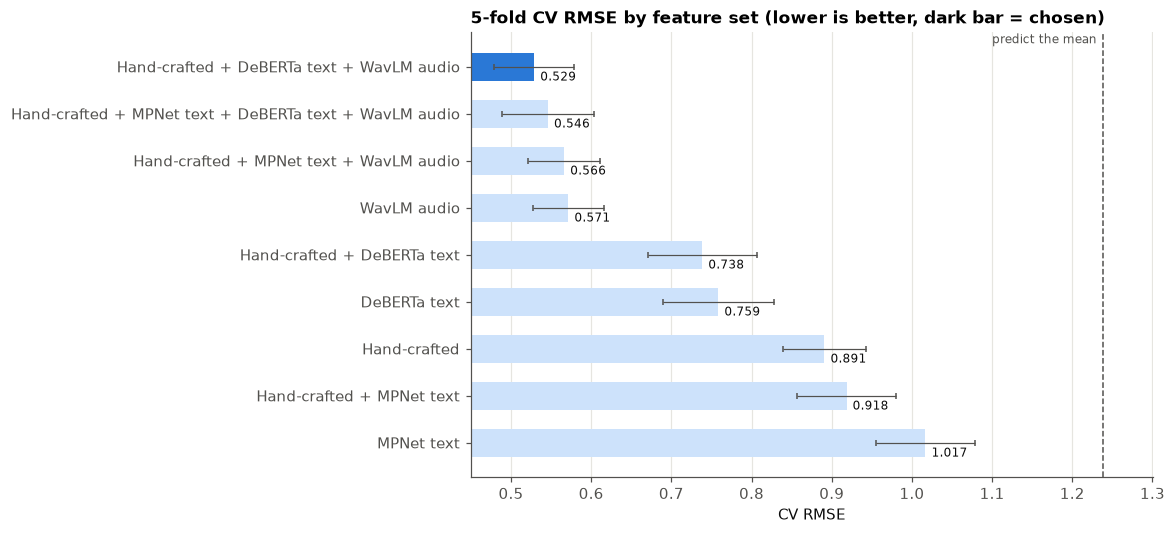

In [11]:
order = ablation.sort_values("cv_rmse", ascending=False)
baseline = y.std()

fig, ax = plt.subplots(figsize=(8, 0.45 * len(order) + 1.2))
colors = [BLUE if name == final_name else LIGHT_BLUE for name in order.index]
ax.barh(order.index, order["cv_rmse"], xerr=order["cv_rmse_fold_std"], color=colors, height=0.6,
        error_kw=dict(ecolor=MUTED, lw=0.8, capsize=2))
ax.axvline(baseline, color=MUTED, linestyle="--", linewidth=1)
ax.annotate("predict the mean", (baseline, len(order) - 0.5), xytext=(-4, 0), textcoords="offset points",
            ha="right", color=MUTED, fontsize=8)
for i, v in enumerate(order["cv_rmse"]):
    ax.annotate(f"{v:.3f}", (v, i), xytext=(4, -9), textcoords="offset points", color=INK, fontsize=8)
ax.set(title="5-fold CV RMSE by feature set (lower is better, dark bar = chosen)", xlabel="CV RMSE",
       xlim=(min(order["cv_rmse"].min() * 0.85, baseline * 0.7), baseline * 1.05))
ax.grid(axis="y", visible=False)
plt.show()

## 8. Final model: CV metrics and training RMSE

The chosen feature set is cross-validated once more to get the per-fold numbers, then a single model is fitted on **all** training clips. That full model is used for the training RMSE (required by the brief) and for the test predictions.

The training RMSE is measured on clips the model was fitted on, so it is optimistic. The CV RMSE is the honest estimate of how the model does on new speakers, and it is the number that should be compared with the leaderboard.

In [12]:
X_all = np.hstack([feature_groups[g] for g in final_name.split(" + ")])
X_train, X_test = X_all[is_train], X_all[~is_train]

oof, fold_table = cross_validate(X_train, y)
final_model = make_model().fit(X_train, y)
train_pred = predict_clipped(final_model, X_train)

results = pd.DataFrame({
    "RMSE": [rmse(y, oof), rmse(y, train_pred), rmse(y, np.full_like(y, y.mean()))],
    "Pearson r": [pearson(y, oof), pearson(y, train_pred), np.nan],
}, index=["5-fold CV (out-of-fold)", "Training set (model fitted on all clips)", "Baseline: predict the mean"])

print(f"Feature set: {final_name} ({X_all.shape[1]} features), ridge alpha on full data = {final_model[-1].alpha_:.3g}")
print(f"\nTRAINING RMSE: {rmse(y, train_pred):.4f}")
print(f"CV RMSE:       {rmse(y, oof):.4f}  (fold mean {fold_table['rmse'].mean():.4f} +/- {fold_table['rmse'].std():.4f})")
print(f"CV Pearson r:  {pearson(y, oof):.4f}\n")
display(results.round(4))
fold_table.round(4)

Feature set: Hand-crafted + DeBERTa text + WavLM audio (1807 features), ridge alpha on full data = 562

TRAINING RMSE: 0.3507
CV RMSE:       0.5289  (fold mean 0.5269 +/- 0.0499)
CV Pearson r:  0.9047



,RMSE,Pearson r
5-fold CV (out-of-fold),0.529,0.905
Training set (model fitted on all clips),0.351,0.961
Baseline: predict the mean,1.238,NaN


,fold,rmse,pearson,alpha
0,1,0.605,0.868,1000.000
1,2,0.469,0.924,562.341
2,3,0.515,0.913,1000.000
3,4,0.537,0.908,1000.000
4,5,0.508,0.911,562.341


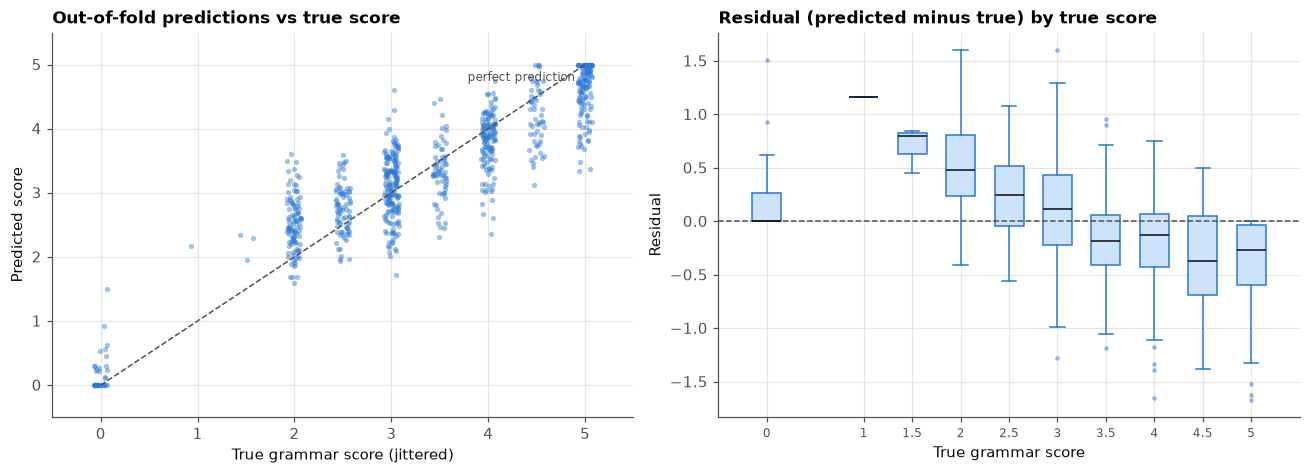

In [13]:
rng = np.random.default_rng(SEED)
jitter = rng.uniform(-0.15, 0.15, len(y)) * step  # spread out the discrete true scores so points do not overlap
lo, hi = SCORE_RANGE

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.scatter(y + jitter, oof, s=12, color=BLUE, alpha=0.45, linewidths=0)
ax1.plot([lo, hi], [lo, hi], color=MUTED, linestyle="--", linewidth=1)
ax1.annotate("perfect prediction", (hi - 0.1, hi - 0.1), ha="right", va="top", color=MUTED, fontsize=8)
ax1.set(title="Out-of-fold predictions vs true score", xlabel="True grammar score (jittered)",
        ylabel="Predicted score", xlim=(y.min() - 0.5, y.max() + 0.5), ylim=(y.min() - 0.5, y.max() + 0.5))

residual = oof - y
groups = [residual[y == s] for s in scores]
ax2.boxplot(groups, positions=scores, widths=0.6 * step, patch_artist=True, showfliers=True,
            boxprops=dict(facecolor=LIGHT_BLUE, edgecolor=BLUE), medianprops=dict(color=INK),
            whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
            flierprops=dict(marker="o", markersize=3, markerfacecolor=BLUE, markeredgecolor="none", alpha=0.5))
ax2.axhline(0, color=MUTED, linestyle="--", linewidth=1)
ax2.set(title="Residual (predicted minus true) by true score", xlabel="True grammar score", ylabel="Residual")
ax2.set_xticks(scores, [f"{s:g}" for s in scores], fontsize=8)
fig.tight_layout()
plt.show()

**Reading the plots.** Points should follow the dashed diagonal. The residual boxes show the typical pattern of a regression model on a crowded middle: low scores are over-predicted (boxes above zero) and high scores under-predicted (boxes below zero). The model is cautious at the extremes because those clips are rare and the squared-error loss rewards staying near the middle.

## 9. What the model learned

Embedding dimensions have no individual meaning, so interpretation is done on the hand-crafted features. The chart on the left repeats the one-feature-at-a-time correlation; the chart on the right shows the weights of a ridge model trained on the hand-crafted features alone (features are standardised, so weights are comparable: the change in predicted score for a one standard deviation change in the feature, holding the others fixed). Features that carry the same information share the weight between them, which is why a feature can correlate strongly but get a small weight.

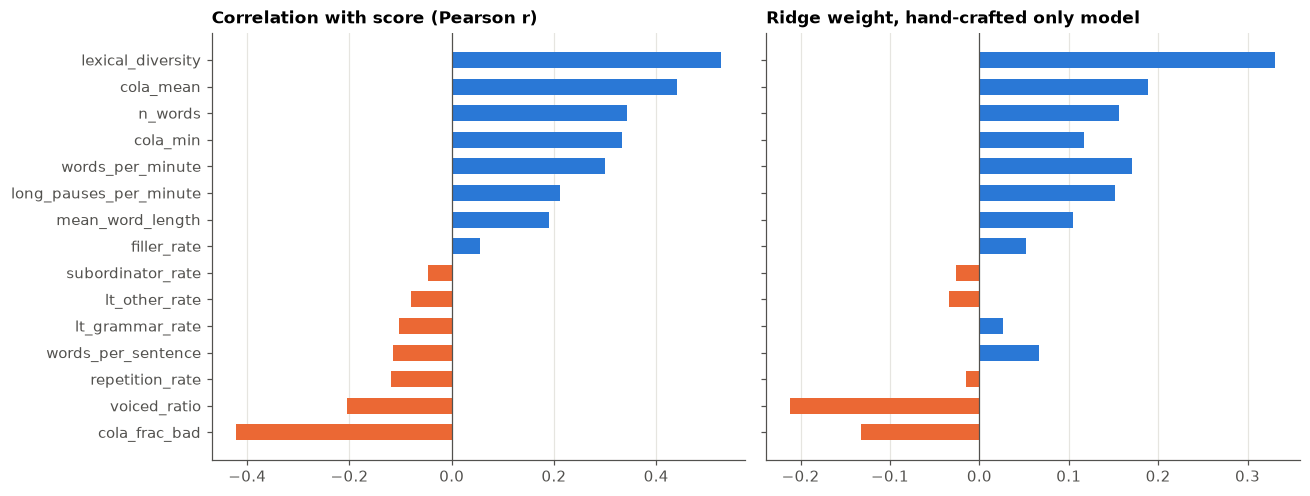

Hand-crafted only: CV RMSE 0.8909, Pearson 0.6979


In [14]:
hc_model = make_model().fit(hc_train.to_numpy(dtype=float), y)
weights = pd.Series(hc_model[-1].coef_, index=hc_train.columns).reindex(corr.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
for ax, values, title in [(ax1, corr, "Correlation with score (Pearson r)"),
                          (ax2, weights, "Ridge weight, hand-crafted only model")]:
    ax.barh(values.index, values.values, color=[ORANGE if v < 0 else BLUE for v in values.values], height=0.6)
    ax.axvline(0, color=MUTED, linewidth=0.8)
    ax.set(title=title)
    ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

hc_oof, _ = cross_validate(hc_train.to_numpy(dtype=float), y)
print(f"Hand-crafted only: CV RMSE {rmse(y, hc_oof):.4f}, Pearson {pearson(y, hc_oof):.4f}")

## 10. Test predictions and submission

The final model (fitted on all training clips) predicts the test clips. Predictions are clipped to the valid 0 to 5 range and written in the exact format of `sample_submission.csv`.

In [15]:
test_pred = predict_clipped(final_model, X_test)
test_ids = clips.loc[~is_train, "file_id"]
submission = write_submission(test_ids, test_pred, sub_columns, OUTPUT_DIR / "submission.csv")
print(f"Wrote {OUTPUT_DIR / 'submission.csv'} with {len(submission)} rows")
display(submission.head())

pd.DataFrame({"file_id": train["file_id"], "label": y, "oof_pred": oof}).to_csv(OUTPUT_DIR / "oof_predictions.csv", index=False)
ablation.to_csv(OUTPUT_DIR / "cv_results.csv")

Wrote C:\Users\archa\Project\shl-grammar-scoring\outputs\submission.csv with 216 rows


,filename,label
0,audio_128.wav,3.123
1,audio_156.wav,4.156
2,audio_19.wav,4.389
3,audio_108.wav,2.144
4,audio_206.wav,1.914


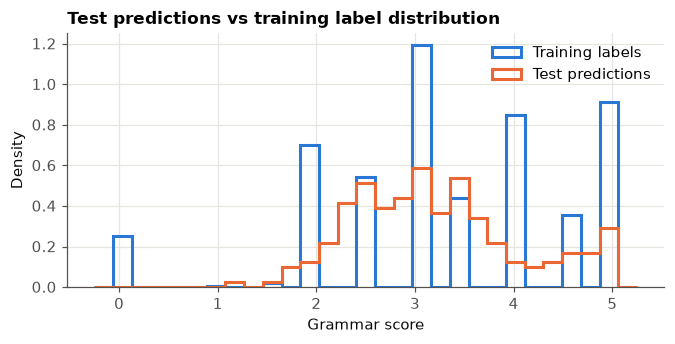

In [16]:
bins = np.linspace(min(y.min(), test_pred.min()) - 0.25, max(y.max(), test_pred.max()) + 0.25, 30)
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y, bins=bins, density=True, histtype="step", linewidth=2, color=BLUE, label="Training labels")
ax.hist(test_pred, bins=bins, density=True, histtype="step", linewidth=2, color=ORANGE, label="Test predictions")
ax.set(title="Test predictions vs training label distribution", xlabel="Grammar score", ylabel="Density")
ax.legend()
plt.show()

The test predictions cover a narrower range than the training labels. That is expected from any regression model that is unsure at the extremes (see the residual plot), and it is the main place where a better model would gain.

## 11. Report summary

**Approach.** Each clip is transcribed with Whisper `medium.en` on a Kaggle GPU. From the transcript and the audio we build three kinds of input: 15 hand-crafted features tied to the rubric (length, speech rate, pauses, sentence length, subordinate clauses, vocabulary, fillers, repetitions, LanguageTool and CoLA grammar scores), pretrained text embeddings (MPNet, DeBERTa), and a pretrained audio embedding (WavLM). A ridge regression maps them to the score, and predictions are clipped to 0 to 5.

**Preprocessing.** Audio is resampled to 16 kHz mono. Transcripts are used as Whisper returns them. Features with missing values (a clip with no complete sentence has no CoLA score) are filled with the training median, and every column is standardised inside the model pipeline, so nothing from the validation fold leaks into training.

**Pipeline architecture.** Heavy pretrained models run once on Kaggle and their outputs are cached (`outputs/`). Everything after that (features, model, evaluation) runs on a CPU in about a minute. The code is split into `src/data.py` (loading and alignment checks), `src/features.py` (hand-crafted features) and `src/train.py` (model, CV and metrics).

**Evaluation.** The metrics table in section 8 reports the 5-fold CV RMSE and Pearson correlation, the training RMSE, and the predict-the-mean baseline. Feature groups were chosen only by CV (section 7).

**Limits and next steps.** Whisper tends to clean up speech (it drops many fillers and sometimes fixes small errors), so some grammar mistakes never reach the text features. Extreme scores are under-represented and the model is cautious there. The next steps, each to be kept only if CV improves, would be scoring with a larger Whisper model, blending a ridge model per feature group, and calibrating predictions at the extremes.